In [1]:
import nltk

In [5]:
#nltk.download_shell()

In [2]:
messages = [line.rstrip() for line in open('smsspamcollection/SMSSpamCollection')]

In [5]:
messages[0]

'ham\tGo until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [7]:
for mess_no, message in enumerate(messages[:10]):
    print(mess_no + 1, message)
    print()

1 ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2 ham	Ok lar... Joking wif u oni...

3 spam	Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

4 ham	U dun say so early hor... U c already then say...

5 ham	Nah I don't think he goes to usf, he lives around here though

6 spam	FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, Â£1.50 to rcv

7 ham	Even my brother is not like to speak with me. They treat me like aids patent.

8 ham	As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune

9 spam	WINNER!! As a valued network customer you have been selected to receivea Â£900 prize reward! To claim call 09061701461. Claim code KL341.

In [9]:
import pandas as pd

In [11]:
messages = pd.read_csv('smsspamcollection/SMSSpamCollection', sep='\t', names=['label', 'message'])

In [23]:
messages.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
messages.groupby('label').describe()

message                                                               
        count unique                                                top freq
label                                                                       
ham      4825   4516                             Sorry, I'll call later   30
spam      747    653  Please call our customer service representativ...    4

In [15]:
messages['length'] = messages['message'].apply(len)

In [17]:
messages.head()

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: ylabel='Frequency'>

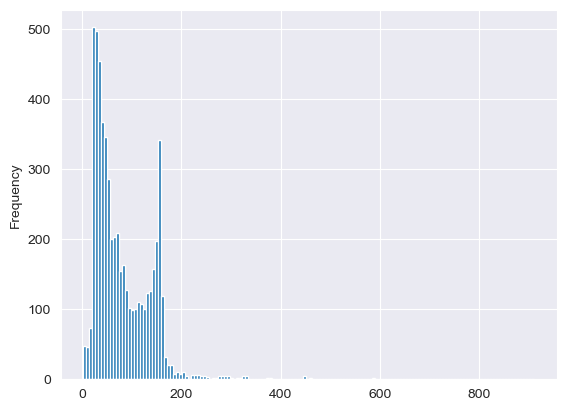

In [20]:
sns.set_style('darkgrid')
messages['length'].plot.hist(bins=150)

In [23]:
messages['length'].describe()

count    5572.000000
mean       80.489950
std        59.942907
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: length, dtype: float64

In [25]:
messages[messages['length'] == messages['length'].max()]['message'].iloc[0]

"For me the love should start with attraction.i should feel that I need her every time around me.she should be the first thing which comes in my thoughts.I would start the day and end it with her.she should be there every time I dream.love will be then when my every breath has her name.my life should happen around her.my life will be named to her.I would cry for her.will give all my happiness and take all her sorrows.I will be ready to fight with anyone for her.I will be in love when I will be doing the craziest things for her.love will be when I don't have to proove anyone that my girl is the most beautiful lady on the whole planet.I will always be singing praises for her.love will be when I start up making chicken curry and end up makiing sambar.life will be the most beautiful then.will get every morning and thank god for the day because she is with me.I would like to say a lot..will tell later.."

array([<Axes: title={'center': 'ham'}>, <Axes: title={'center': 'spam'}>],
      dtype=object)

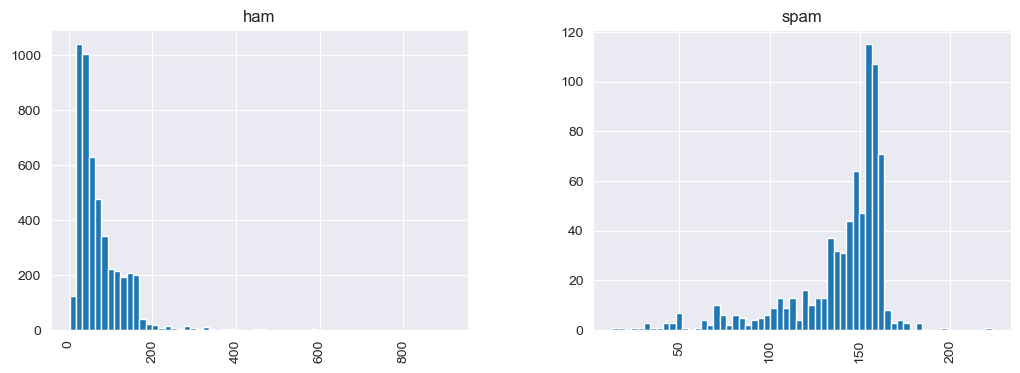

In [27]:
messages.hist(column='length', by='label', bins=60, figsize=(12, 4))

In [29]:
import string
from nltk.corpus import stopwords

In [31]:
# These are words that are so common which they won't really help us in classification, like if it is a spam or ham
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [37]:
mess = "Here is a message! that has some punctuations."
no_punc = ''.join([ch for ch in mess if ch not in string.punctuation])
clean_mess = ' '.join([word for word in no_punc.split() if word.lower() not in stopwords.words('english')])
clean_mess

'message punctuations'

In [39]:
def text_process(mess):
    """
    1. remove punc
    2. remove stop words
    3. return list of clean text words
    """
    
    no_punc = ''.join([ch for ch in mess if ch not in string.punctuation])
    return [word for word in no_punc.split() if word.lower() not in stopwords.words('english')]

# this process is called Tokenization: convert a normal text string into a list of tokens (the words that we actually want)
# Stemming is the process of just returning the origin of the word, like if you have running ran run, these will be converted to run.

In [41]:
from sklearn.feature_extraction.text import CountVectorizer

In [43]:
# bow = bag of words
bow_transfomer = CountVectorizer(analyzer=text_process).fit(messages['message'])

In [45]:
print(len(bow_transfomer.vocabulary_))

11425


In [47]:
mess4 = messages['message'][3]
print(mess4)

U dun say so early hor... U c already then say...


In [49]:
bow4 = bow_transfomer.transform([mess4])
print(bow4)
# the index,    how many time the word appeared, and the total is the total unique words

  (0, 4068)	2
  (0, 4629)	1
  (0, 5261)	1
  (0, 6204)	1
  (0, 6222)	1
  (0, 7186)	1
  (0, 9554)	2


In [51]:
bow_transfomer.get_feature_names_out()[4068] # getting the word by index

'U'

In [53]:
messages_bow = bow_transfomer.transform(messages['message'])

In [55]:
print('Shape of Sparse Matrix: ', messages_bow.shape)

Shape of Sparse Matrix:  (5572, 11425)


In [57]:
# non zero accurances: 
messages_bow.nnz

50548

In [59]:
# percent of non zero messages to the total number of messages: 
sparcity = (100 * messages_bow.nnz / (messages_bow.shape[0] * messages_bow.shape[1]))
print(f"sparcity: rounded {round(sparcity)}, not rounded {sparcity}")

sparcity: rounded 0, not rounded 0.07940295412668218


In [97]:
# Tfidf: Term frequency inverse document frequency 
from sklearn.feature_extraction.text import TfidfTransformer

In [63]:
tfidf_transformer = TfidfTransformer().fit(messages_bow)

In [65]:
tfidf4 = tfidf_transformer.transform(bow4)

In [71]:
print(tfidf4)

  (0, 4068)	0.4083258993338407
  (0, 4629)	0.2661980190608719
  (0, 5261)	0.2972995740586873
  (0, 6204)	0.2995379972369742
  (0, 6222)	0.31872168929491496
  (0, 7186)	0.4389365653379858
  (0, 9554)	0.5385626262927565


In [73]:
tfidf_transformer.idf_[bow_transfomer.vocabulary_['university']]

8.527076498901426

In [77]:
messages_tfidf = tfidf_transformer.transform(messages_bow)

In [79]:
from sklearn.naive_bayes import MultinomialNB

In [81]:
spam_detect_model = MultinomialNB().fit(messages_tfidf, messages['label'])

In [83]:
spam_detect_model.predict(tfidf4)[0]

'ham'

In [85]:
messages['label'][3]

'ham'

In [87]:
all_pred = spam_detect_model.predict(messages_tfidf)

In [89]:
all_pred

array(['ham', 'ham', 'spam', ..., 'ham', 'ham', 'ham'], dtype='<U4')

In [91]:
from sklearn.model_selection import train_test_split

In [93]:
msg_train, msg_test, label_train, label_test = train_test_split(messages['message'], messages['label'], test_size=0.3)

In [95]:
# sklearn has some bulit-in features that saves time to not make this same steps above
from sklearn.pipeline import Pipeline

In [99]:
pipline = Pipeline([
    ('bow', CountVectorizer(analyzer=text_process)),
    ('tfidf', TfidfTransformer()),
    ('classifier', MultinomialNB())
])

In [103]:
pipline.fit(msg_train, label_train)

Pipeline(steps=[('bow',
                 CountVectorizer(analyzer=<function text_process at 0x0000013BCA759440>)),
                ('tfidf', TfidfTransformer()),
                ('classifier', MultinomialNB())])

In [105]:
predictions = pipline.predict(label_test)

In [107]:
from sklearn.metrics import classification_report, confusion_matrix

In [111]:
print(classification_report(label_test, predictions))
# print(confusion_matrix(label_test, predictions))

              precision    recall  f1-score   support

         ham       0.89      1.00      0.94      1484
        spam       0.00      0.00      0.00       188

    accuracy                           0.89      1672
   macro avg       0.44      0.50      0.47      1672
weighted avg       0.79      0.89      0.83      1672



C:\Users\Aminpatra\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Aminpatra\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Aminpatra\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
